### Import Libraries

In [1]:
import xarray as xr
import OpenVisus as ov
import numpy as np
import matplotlib.pyplot as plt

### Extract Latitude and Longitude from the netcdf file

Please download the netcdf file from the same github repo or from here: https://mega.nz/file/7N8xEa4S#I756lI6N0uf2xaAEDOno2belVW7aX2lv5W1pLFvuRQ4 

Please send an email to aashishpanta0@gmail.com if you have trouble accessing it.

In [2]:
ds=xr.open_dataset('./llc2160_latlon.nc')
lat_center = ds["latitude"].values
lon_center = ds["longitude"].values

### Set Variables

In [ ]:
eastwest_ocean_velocity_u = "https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/mit_output/llc2160_arco/visus.idx"
northsouth_ocean_velocity_v = "https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/mit_output//llc2160_v/v_llc2160_x_y_depth.idx"
vertical_velocity_w = "https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/mit_output/llc2160_w/llc2160_w.idx"
temperature_theta = "https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/mit_output//llc2160_theta/llc2160_theta.idx"
Salinity_salt = "https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/mit_output/llc2160_salt/salt_llc2160_x_y_depth.idx"


### Use Array Index to extract Data and Lat/Lon

In [4]:
def extract_data_latlon(field, lat_center, lon_center, x_range, y_range, z=[0,1], quality=0):
    db=ov.LoadDataset(field)
    data = db.read(x=x_range, y=y_range, z=z, quality=quality)[0, :, :]
    lat = lat_center[y_range[0]:y_range[1], x_range[0]:x_range[1]]
    lon = lon_center[y_range[0]:y_range[1], x_range[0]:x_range[1]]
    return data, lat, lon


In [5]:
x_range = [3400, 4800]
y_range = [2600, 3800]
data_sub, lat_sub, lon_sub = extract_data_latlon(Salinity_salt, lat_center, lon_center, x_range, y_range)

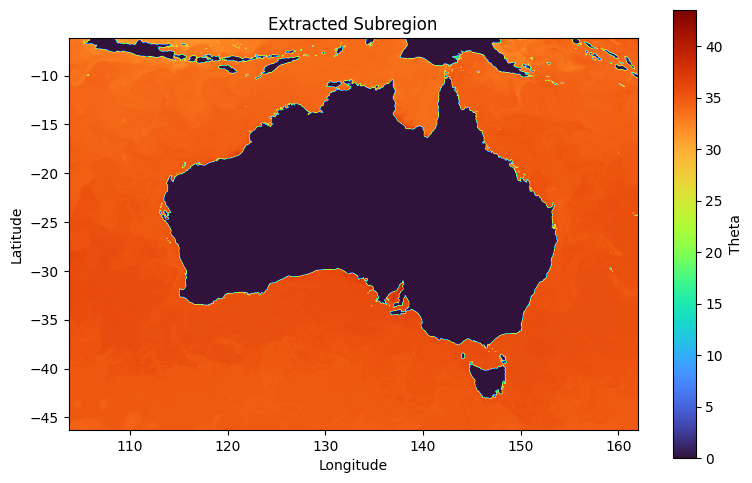

In [6]:
plt.figure(figsize=(8, 5))
plt.imshow(data_sub, cmap="turbo", origin="lower", extent=[
    lon_sub.min(), lon_sub.max(), lat_sub.min(), lat_sub.max()
])
plt.colorbar(label="Theta")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Extracted Subregion")
plt.tight_layout()
plt.show()


### Use Lat/Lon to extract corresponding data

In [7]:
def extract_data_by_latlon_range(field, lat_center, lon_center, 
                                  lat_range, lon_range, z=[0,1], quality=0):
    db = ov.LoadDataset(field)
    
    mask = (
        (lat_center >= lat_range[0]) & (lat_center <= lat_range[1]) &
        (lon_center >= lon_range[0]) & (lon_center <= lon_range[1])
    )

    y_indices, x_indices = np.where(mask)

    if len(x_indices) == 0 or len(y_indices) == 0:
        raise ValueError("No data found in the given lat/lon range.")

    x_min = int(x_indices.min())
    x_max = int(x_indices.max()) + 1
    y_min = int(y_indices.min())
    y_max = int(y_indices.max()) + 1

    data = db.read(x=[x_min, x_max], y=[y_min, y_max], z=z, quality=quality)[0, :, :]
    lat = lat_center[y_min:y_max, x_min:x_max]
    lon = lon_center[y_min:y_max, x_min:x_max]

    return data, lat, lon

In [8]:
lat_range = [-40, 10]
lon_range = [105, 160]

data, lat, lon = extract_data_by_latlon_range(Salinity_salt, lat_center, lon_center, lat_range, lon_range)


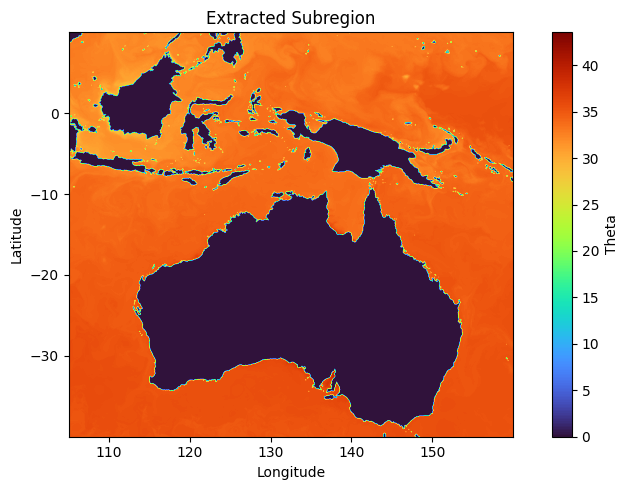

In [9]:
plt.figure(figsize=(8, 5))
plt.imshow(data, cmap="turbo", origin="lower", extent=[
    lon.min(), lon.max(), lat.min(), lat.max()])
plt.colorbar(label="Theta")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Extracted Subregion")
plt.tight_layout()
plt.show()